# TensorBinding.jl — Getting Started

End-to-end tour of the core workflows:

1. **1D chain** — KPM density matrix, LDoS, and A(k,ω) band structure via QFT
2. **NNN hopping** — `add_hopping!` to extend an existing Hamiltonian
2b. **AAH quasicrystal** — quasiperiodic on-site potential, localisation transition
2c. **Custom MPO** — arbitrary hopping matrix compressed via TCI
3. **2D square lattice** — density matrix via McWeeny and SP2 purification
4. **2D LDoS** — local spectral function at the sample centre
5. **Real-time TDVP** — `evolve_with_tdvp`, wavepacket spreading
6. **Driven lattice** — Peierls field, RK4 density-matrix evolution, HHG spectrum
7. **Bilayer graphene** — exact Bernal interlayer coupling, MPO-KPM vs exact diag
8. **SSH model** — DoS via Krylov Green's function
9. **RPA susceptibility** — Wynn ε-algorithm with purification-based density matrix

All physics functions live in `TensorBinding`; the central object is `TBHamiltonian`
returned by `get_Hamiltonian`.

In [ ]:
# import Pkg; Pkg.resolve(); Pkg.instantiate() # uncomment to install dependencies if needed

In [22]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding
using QuanticsTCI
import TensorCrossInterpolation as TCI

---
## 1. 1D nearest-neighbour chain

$$H = -t \sum_{\langle i,j \rangle} c_i^\dagger c_j$$

`L = 8` qubits encodes `N = 2^8 = 256` physical sites in the quantics binary representation.

The `TBHamiltonian` struct wraps the MPO together with `sites`, `scale`, `center`, and lazy
Chebyshev caches.  For preset models an analytic scale estimate is set at construction.
For custom or layered systems `scale=0` until the first `KPM_Tn` call, at which point
spectral bounds are estimated automatically via two short DMRG sweeps and cached in
`H.scale` / `H.center` for all subsequent calls.


In [10]:
L  = 5
H1 = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L, scale=4.5)
println(H1)

TBHamiltonian | L=5, N=32, scale=4.5, maxlinkdim=3 | geometry: 32 sites, 1D | no Tn cache


### 1a. Density matrix via KPM

The Chebyshev list `Tn_list` is built **once** by passing the `TBHamiltonian` directly to
`KPM_Tn(H, Ncheb; ...)`.  For preset models the spectral bounds are analytic; for custom
or layered systems they are estimated automatically via two short DMRG sweeps on the first
call and cached in `H.scale` / `H.center`.

`KPM_Tn` returns `(Tn_list, scale, center)`.  The rescaled energy axis is
`ω_resc = (ω_phys .- center) ./ scale ∈ (−1, 1)`.

At half-filling (Fermi level `μ = 0`) we expect `Tr(ρ) ≈ N/2 = 128`.

In [3]:
Ncheb  = 30
maxdim = 100

Tn_list, _, _ = TensorBinding.KPM_Tn(H1, Ncheb; maxdim=maxdim, cutoff=1e-5, verbose=true)

println(H1)

# Half-filled density matrix (μ = 0 → rescaled fermi = (0 - center) / scale)
ρ_kpm = TensorBinding.get_density_from_Tn(Tn_list, Ncheb;
            fermi=(0.0 - H1.center) / H1.scale, maxdim=maxdim)

println("maxlinkdim(ρ) = ", ITensorMPS.maxlinkdim(ρ_kpm))
println("Tr(ρ)         = ", real(tr(ρ_kpm)), "  (expected ≈ N/2 = ", H1.N ÷ 2, ")")

Computed T_9 with maxlinkdim = 6
Computed T_19 with maxlinkdim = 9
Computed T_29 with maxlinkdim = 10
Computed T_30 with maxlinkdim = 9
TBHamiltonian | L=5, N=32, scale=4.5, maxlinkdim=3 | geometry: 32 sites, 1D | Tn cached (Ncheb = 30)
maxlinkdim(ρ) = 7
Tr(ρ)         = 15.999999892470685  (expected ≈ N/2 = 16)


### 1b. Local density of states (LDoS)

$$\text{LDoS}(i,\omega) = \langle i \mid \delta(\omega - H) \mid i \rangle$$

Evaluated at the central site by contracting the spectral MPO `δ(ω−H)` with the
computational-basis state `|i⟩`.  Energies are converted to **rescaled** units with
`ω_resc = (ω_phys .- center) ./ scale ∈ (−1, 1)`.

The 1D chain has square-root van Hove singularities at the band edges `±2t`.

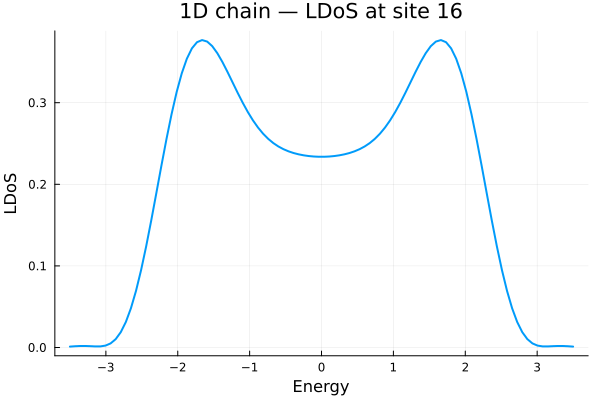

In [4]:
ω_phys = range(-3.5, 3.5; length=100)

site_idx  = H1.N ÷ 2
psi_site  = TensorBinding.binary_to_MPS(site_idx, H1.L, H1.sites)
ldos_1d   = Float64[]

for ω_p in ω_phys
    if abs((ω_p - H1.center) / H1.scale) >= 1.0
        push!(ldos_1d, 0.0); continue
    end
    A_mpo = TensorBinding.get_ldos(H1, ω_p; maxdim=maxdim)
    push!(ldos_1d, real(inner(psi_site, apply(A_mpo, psi_site))))
end

plot(ω_phys, ldos_1d;
     xlabel="Energy", ylabel="LDoS",
     title="1D chain — LDoS at site $(site_idx)",
     legend=false, lw=2)

### 1b-mps. LDoS via MPS-based KPM (`KPM_Tn_mps`)

Instead of storing `Ncheb` Chebyshev MPOs, `KPM_Tn_mps` propagates a single
reference MPS and computes moments mu_n = inner(psi, T_n(H)|psi).

Pass moments to `get_ldos_from_mun` (Jackson) or `get_ldos_hodc_from_mun` (HODC),
or use the unified `get_ldos(...; kpm_type=:mps)` dispatcher.

**Advantage**: MPS vectors instead of MPOs — memory-efficient for site LDoS.

Computed MPS T_9 with maxlinkdim = 4
Computed MPS T_19 with maxlinkdim = 4
Computed MPS T_29 with maxlinkdim = 4
Computed MPS T_30 with maxlinkdim = 4
TBHamiltonian | L=5, N=32, scale=4.5, maxlinkdim=3 | geometry: 32 sites, 1D | Tn cached (Ncheb = 30)


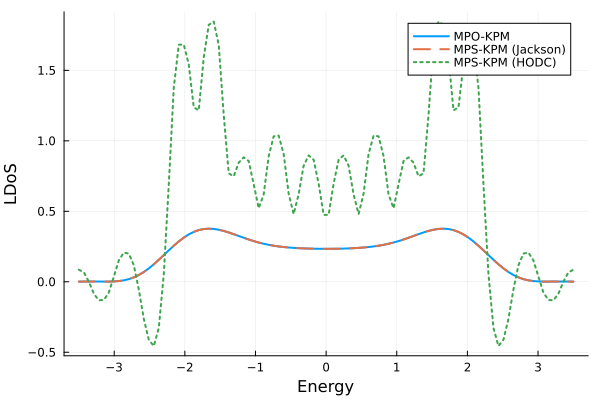

In [6]:
ω_phys = range(-3.5, 3.5; length=100)

# MPS Chebyshev expansion — stored in H1._tn_mps_cache, independent of the MPO cache
TensorBinding.KPM_Tn(H1, Ncheb; mode=:mps, psi0=psi_site, maxdim=maxdim, verbose=true)

println(H1)

ldos_mps      = [TensorBinding.get_ldos(H1, ω_p; mode=:mps, psi0=psi_site,
                     kernel=:jackson, eta=1/(Ncheb-1)) for ω_p in ω_phys]
ldos_mps_hodc = [TensorBinding.get_ldos(H1, ω_p; mode=:mps, psi0=psi_site,
                     kernel=:hodc, eta=1/(Ncheb-1)) for ω_p in ω_phys]

plot(ω_phys, ldos_1d; label="MPO-KPM", lw=2, xlabel="Energy", ylabel="LDoS")
plot!(ω_phys, ldos_mps;       label="MPS-KPM (Jackson)", lw=2, ls=:dash)
plot!(ω_phys, ldos_mps_hodc;  label="MPS-KPM (HODC)",   lw=2, ls=:dot)

### 1c. Band structure A(k,ω) via QFT

In the quantics representation the `L` qubit sites encode real-space position in binary.
The QFT maps this to momentum space. The correct spectral function is:

$$A(k,\omega) = \langle k \mid F\,\delta(\omega - H)\,F^\dagger \mid k \rangle$$

The k-states are encoded **LSB-first** to match the `QuanticsTCI` QFT convention.
`get_bands` pre-builds the QFT operators once and loops over ω, reusing `Tn_list`.
The result is a `(N_k × N_ω)` matrix displayed as a heatmap.


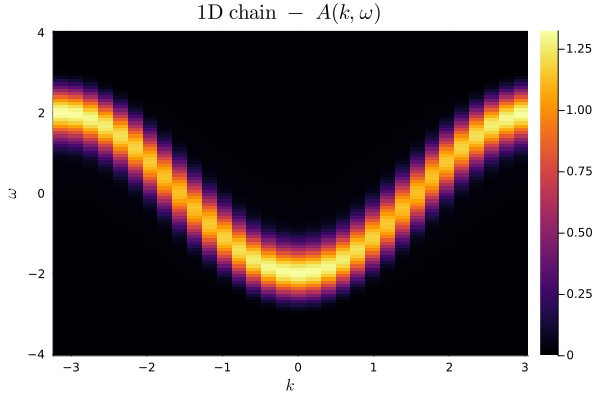

In [18]:
using LaTeXStrings

Ncheb  = 30
maxdim = 100

e_phys = range(-4, 4; length=100)

Ak = TensorBinding.get_bands(H1,
                          Ncheb, e_phys; num_x = H1.N);

kvals = (2π / H1.N) .* range(0, H1.N-1; length=H1.N) .- π   # BZ: [-π, π)

heatmap(kvals, e_phys,           # x and y axes
        Ak;                      # data
        xlabel=L"k", ylabel=L"\omega",
        title=L"\mathrm{1D\ chain\ -\ } A(k,\omega)",
        color=:inferno, clims=(0, maximum(Ak)))

#### 1d. Band structure of the SSH chain

In [26]:
L  = 6
t1 = 1.0
t2 = 0.5

tt(x) = mod(x,2) == 1 ? t1+t2 : t1-t2

H1 = TensorBinding.get_Hamiltonian("ssh", Dict(:t => 1, :d => t2), L=L; scale=5.5)
# TensorBinding.add_hopping!(H1, (i, j) -> abs(i - j) == 1 ? tt(i) : 0.001; type=Float64)
TensorBinding.truncate!(H1; cutoff=1e-6)

Ncheb  = 30
maxdim = 100

e_phys = range(-3, 3; length=100)

Ak = TensorBinding.get_bands(H1,
                          Ncheb, 1, e_phys; num_x = 2^L, sublattice=true);



                          

KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -1.9983,  E_max = 1.9975
  center = -0.0004,  scale = 2.1977


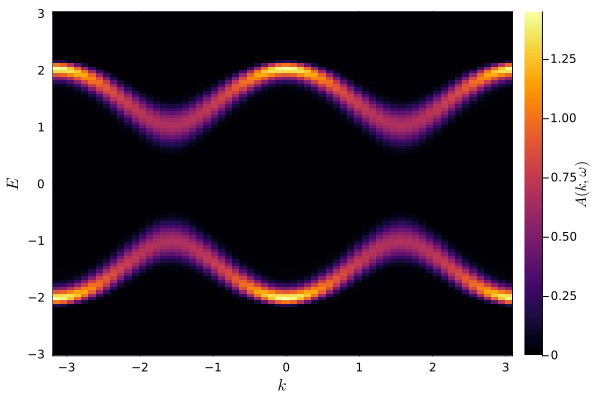

In [27]:
kvals = (2π / H1.N) .* range(0, H1.N-1; length=H1.N) .- π   # BZ: [-π, π)

heatmap(
      kvals, e_phys,           # x and y axes
      Ak;        # data
    #   title             =  titles[i],
      xlabel            = L"k",
      ylabel            = L"E" ,
      color             = :inferno,
      aspect_ratio      = :auto,
      flipy             = true,
      framestyle        = :box,
      legend            = false,
      colorbar          = true, 
      # cbar_ticks        = [0.00001, cmax/2, cmax],
      cbar_tickfontsize = 10,
      cbar_title         =  L"A(k,\omega)",
      cbar_titlefontsize = 12
    )

---
## 2. Adding second-neighbour hopping with `add_hopping!`

`add_hopping!(H, f)` compresses `f(i,j)` via TCI and adds it to the existing MPO,
automatically invalidating the Chebyshev cache.

$$H = -t_1 \sum_{|i-j|=1} c_i^\dagger c_j - t_2 \sum_{|i-j|=2} c_i^\dagger c_j$$

Exact dispersion: $\varepsilon(k) = -2t_1 \cos k - 2t_2 \cos 2k$,
overlaid as a dashed curve on the A(k,ω) heatmap.


In [3]:
t1 = 1.0
t2 = 0.3

H2 = TensorBinding.get_Hamiltonian("chain_1d", t1; L=L, scale=5.5)
TensorBinding.add_hopping!(H2, (i, j) -> abs(i - j) == 2 ? -t2 : 0.0; type=Float64)
TensorBinding.truncate!(H2; cutoff=1e-6)
println(H2)

MPS COMPUTED!
Turned into MPO!
TBHamiltonian | L=5, N=32, scale=auto, maxlinkdim=4 | geometry: 32 sites, 1D | no Tn cache


In [ ]:
Ncheb_nnn  = 80
TensorBinding.KPM_Tn(H2, Ncheb_nnn; maxdim=maxdim)

In [ ]:
ω_phys_nnn = range(-5.0, 5.0; length=120)

Ak_w_nnn = TensorBinding.get_bands(H2, ω_phys_nnn; tol=1e-9, maxdim=100)

k_axis_nnn = (2π / H2.N) .* (0:H2.N-1) .- π

p = heatmap(k_axis_nnn, collect(ω_phys_nnn), Ak_w_nnn';
            xlabel="k", ylabel="ω",
            title="1D chain + NNN — A(k,ω)",
            color=:inferno, clims=(0, maximum(Ak_w_nnn)))

# Overlay exact dispersion
ε_exact = -2t1 .* cos.(k_axis_nnn) .- 2t2 .* cos.(2 .* k_axis_nnn)
plot!(p, k_axis_nnn, ε_exact; lw=1.5, ls=:dash, color=:white, label="exact ε(k)")

---
## 2b. Aubry-Andre-Harper (AAH) quasicrystal

The AAH model adds a quasiperiodic on-site potential:

$$H = -t \sum_{\langle i,j \rangle} c_i^\dagger c_j + V \sum_i \cos(2\pi b\,i + \phi)\,n_i,
\qquad b = \frac{1+\sqrt{5}}{2}$$

Exact localisation transition at $V = 2t$:
- $V < 2t$ — all eigenstates **extended** (metallic), smooth LDoS
- $V > 2t$ — all eigenstates **localised** (insulating), spiky LDoS

Built via `get_Hamiltonian("aah", (V=..., phi=..., t=...); L=L)`.


In [ ]:
# --- Delocalised phase: V < 2t ---
t_aah = 1.0
H_del = TensorBinding.get_Hamiltonian("aah", (V=1.0, phi=0.0, t=t_aah); L=L, scale=4.5)
println(H_del)

# --- Localised phase: V > 2t ---
H_loc = TensorBinding.get_Hamiltonian("aah", (V=3.0, phi=0.0, t=t_aah); L=L, scale=6.5)
println(H_loc)

In [ ]:
Ncheb_aah = 200

TensorBinding.KPM_Tn(H_del, Ncheb_aah; maxdim=maxdim)
TensorBinding.KPM_Tn(H_loc, Ncheb_aah; maxdim=maxdim)

site_c    = H_del.N ÷ 2
psi_c_del = TensorBinding.binary_to_MPS(site_c, H_del.L, H_del.sites)
psi_c_loc = TensorBinding.binary_to_MPS(site_c, H_loc.L, H_loc.sites)

ω_aah_phys = range(-4.0, 4.0; length=120)

ldos_del = Float64[]
ldos_loc = Float64[]
for ω_p in ω_aah_phys
    if abs((ω_p - H_del.center) / H_del.scale) < 1.0
        A = TensorBinding.get_ldos(H_del, ω_p; maxdim=maxdim)
        push!(ldos_del, real(inner(psi_c_del, apply(A, psi_c_del))))
    else
        push!(ldos_del, 0.0)
    end
    if abs((ω_p - H_loc.center) / H_loc.scale) < 1.0
        A = TensorBinding.get_ldos(H_loc, ω_p; maxdim=maxdim)
        push!(ldos_loc, real(inner(psi_c_loc, apply(A, psi_c_loc))))
    else
        push!(ldos_loc, 0.0)
    end
end

pa = plot(ω_aah_phys, ldos_del; label="V=1 (delocalised)", lw=2,
          xlabel="Energy", ylabel="LDoS", title="AAH — LDoS at central site")
plot!(pa, ω_aah_phys, ldos_loc; label="V=3 (localised)", lw=2, ls=:dash)

---
## 2c. Custom MPO — spatially modulated hopping

Pass any function `f(i, j)` to `get_Hamiltonian("custom", f; L, scale)` and TCI
compresses the full `N x N` hopping matrix into an MPO automatically.

Here we use a sinusoidally modulated nearest-neighbour chain:

$$t_{i,i\pm1} = 1 + \delta\cos\!\left(\frac{2\pi i}{\lambda}\right),
\quad \delta = 0.5,\quad \lambda = N/4$$

The spatial modulation breaks translational symmetry; the LDoS at different
sites reveals site-dependent spectral weight redistribution.


In [ ]:
δ_mod  = 0.5
λ_mod  = H1.N / 4

# f(i,j): 1-based site indices, NN hopping with a cosine envelope
f_mod(i, j) = abs(i - j) == 1 ?
    -(1.0 + δ_mod * cos(2π * (i + j - 1) / 2 / λ_mod)) : 0.0

H_cust = TensorBinding.get_Hamiltonian("custom", f_mod;
             L=L, scale=5.0, type=Float64)
println(H_cust)

In [ ]:
Ncheb_cust = 200
TensorBinding.KPM_Tn(H_cust, Ncheb_cust; maxdim=maxdim)

ω_cust_phys = range(-4.0, 4.0; length=120)
sample_sites = [H_cust.N ÷ 8, H_cust.N ÷ 4, H_cust.N ÷ 2]

ldos_cust = [Float64[] for _ in sample_sites]
psi_cust  = [TensorBinding.binary_to_MPS(s, H_cust.L, H_cust.sites) for s in sample_sites]

for ω_p in ω_cust_phys
    if abs((ω_p - H_cust.center) / H_cust.scale) < 1.0
        A = TensorBinding.get_ldos(H_cust, ω_p; maxdim=maxdim)
        for (k, psi) in enumerate(psi_cust)
            push!(ldos_cust[k], real(inner(psi, apply(A, psi))))
        end
    else
        for k in eachindex(psi_cust)
            push!(ldos_cust[k], 0.0)
        end
    end
end

pc = plot(ω_cust_phys, ldos_cust[1]; label="site $(sample_sites[1])", lw=2,
          xlabel="Energy", ylabel="LDoS",
          title="Custom modulated chain — LDoS at selected sites")
for k in 2:length(sample_sites)
    plot!(pc, ω_cust_phys, ldos_cust[k]; label="site $(sample_sites[k])", lw=2)
end
pc

---
## 3. 2D square lattice — density matrix via purification

`L = 8` qubits, `Lx = Ly = 4`, `N = 256` sites. 2D NN bandwidth `≈ 8|t|`, `scale = 9`.

Purification iterates a polynomial map on ρ to drive eigenvalues toward exactly 0 or 1,
approximating $\theta(\mu - H)$ without a Chebyshev expansion.

The `TBHamiltonian` overloads build the initial guess internally using the corrected formula:

$$\rho_0 = \left(\frac{1}{2} + \frac{\mathrm{center}}{2\,\mathrm{scale}}\right) I - \frac{H}{2\,\mathrm{scale}}$$

which maps the physical spectrum to $[0, 1]$ even when `center ≠ 0`.

**Workflow:**
1. `purification_initial_guess(H)`: build $\rho_0$ from `H` (spectrum mapped to $[0,1]$)
2. **McWeeny**: `mcweeny_purify(H; ...)` — $\rho_{n+1} = 3\rho_n^2 - 2\rho_n^3$, quadratic convergence, 2 MPO products/step
3. **SP2**: `sp2_purify(H; Nel=..., ...)` — $\rho_{n+1} = \rho_n^2$ or $2\rho_n - \rho_n^2$ based on $\mathrm{Tr}(\rho^2)$ vs $N_{\mathrm{el}}$, 1 product/step

Both high-level forms cache the purified density matrix in `H._density_cache`.

In [19]:
Lsq = 8
Lx  = 4
H3  = TensorBinding.get_Hamiltonian("square_2d", 1.0; L=Lsq, Lx=Lx, scale=9.0)
println(H3)

TBHamiltonian | L=8, N=256, scale=9.0, maxlinkdim=4 | geometry: 256 sites, 2D | no Tn cache


In [19]:
ρ0 = TensorBinding.purification_initial_guess(H3; maxdim=100, cutoff=1e-8)
println("Tr(ρ₀) = ", real(tr(ρ0)), "  (expected ≈ N/2 = ", H3.N ÷ 2, ")")

Tr(ρ₀) = 127.99999999999987  (expected ≈ N/2 = 128)


In [20]:
ρ_mc = TensorBinding.mcweeny_purify(H3; maxiters=25, maxdim=200, cutoff=1e-8, tol=1e-5, verbose=true)
println("McWeeny → Tr(ρ) = ", real(tr(ρ_mc)),
        "  maxlinkdim = ", ITensorMPS.maxlinkdim(ρ_mc))

McWeeny iter 1: ‖ρ²-ρ‖/‖ρ‖ = 0.466876689094888, maxlinkdim = 4
McWeeny iter 2: ‖ρ²-ρ‖/‖ρ‖ = 0.43399112266890894, maxlinkdim = 9
McWeeny iter 3: ‖ρ²-ρ‖/‖ρ‖ = 0.382364964267818, maxlinkdim = 10
McWeeny iter 4: ‖ρ²-ρ‖/‖ρ‖ = 0.32043910027012446, maxlinkdim = 12
McWeeny iter 5: ‖ρ²-ρ‖/‖ρ‖ = 0.26340237839656183, maxlinkdim = 16
McWeeny iter 6: ‖ρ²-ρ‖/‖ρ‖ = 0.21696857251262375, maxlinkdim = 22
McWeeny iter 7: ‖ρ²-ρ‖/‖ρ‖ = 0.17958830400393744, maxlinkdim = 28
McWeeny iter 8: ‖ρ²-ρ‖/‖ρ‖ = 0.14911718171175434, maxlinkdim = 28
McWeeny iter 9: ‖ρ²-ρ‖/‖ρ‖ = 0.12428221764100027, maxlinkdim = 30
McWeeny iter 10: ‖ρ²-ρ‖/‖ρ‖ = 0.10644806370226259, maxlinkdim = 31
McWeeny iter 11: ‖ρ²-ρ‖/‖ρ‖ = 0.0967378635362263, maxlinkdim = 34
McWeeny iter 12: ‖ρ²-ρ‖/‖ρ‖ = 0.09192814470381425, maxlinkdim = 35
McWeeny iter 13: ‖ρ²-ρ‖/‖ρ‖ = 0.09004931469147444, maxlinkdim = 38
McWeeny iter 14: ‖ρ²-ρ‖/‖ρ‖ = 0.0897230019051855, maxlinkdim = 38
McWeeny iter 15: ‖ρ²-ρ‖/‖ρ‖ = 0.08956637957934074, maxlinkdim = 39
McWeeny iter

In [21]:
ρ_sp2 = TensorBinding.sp2_purify(H3; Nel=H3.N÷2, maxiters=25, maxdim=200, cutoff=1e-8, tol=1e-5, verbose=true)
println("SP2    → Tr(ρ) = ", real(tr(ρ_sp2)),
        "  maxlinkdim = ", ITensorMPS.maxlinkdim(ρ_sp2))

SP2 iter 1: ‖ρ²-ρ‖/‖ρ‖ = 0.466876689094888, maxlinkdim = 4
SP2 iter 2: ‖ρ²-ρ‖/‖ρ‖ = 0.25168685326917395, maxlinkdim = 8
SP2 iter 3: ‖ρ²-ρ‖/‖ρ‖ = 0.3881265625545418, maxlinkdim = 9
SP2 iter 4: ‖ρ²-ρ‖/‖ρ‖ = 0.2098270946936605, maxlinkdim = 9
SP2 iter 5: ‖ρ²-ρ‖/‖ρ‖ = 0.2989731872478103, maxlinkdim = 10
SP2 iter 6: ‖ρ²-ρ‖/‖ρ‖ = 0.17189014122558338, maxlinkdim = 12
SP2 iter 7: ‖ρ²-ρ‖/‖ρ‖ = 0.21910594608580877, maxlinkdim = 13
SP2 iter 8: ‖ρ²-ρ‖/‖ρ‖ = 0.263609210270872, maxlinkdim = 15
SP2 iter 9: ‖ρ²-ρ‖/‖ρ‖ = 0.17735093791330342, maxlinkdim = 16
SP2 iter 10: ‖ρ²-ρ‖/‖ρ‖ = 0.19977291516572104, maxlinkdim = 18
SP2 iter 11: ‖ρ²-ρ‖/‖ρ‖ = 0.14129405628338304, maxlinkdim = 21
SP2 iter 12: ‖ρ²-ρ‖/‖ρ‖ = 0.14986509772628076, maxlinkdim = 24
SP2 iter 13: ‖ρ²-ρ‖/‖ρ‖ = 0.16131188290520332, maxlinkdim = 28
SP2 iter 14: ‖ρ²-ρ‖/‖ρ‖ = 0.12026634134182795, maxlinkdim = 28
SP2 iter 15: ‖ρ²-ρ‖/‖ρ‖ = 0.12378585764853028, maxlinkdim = 28
SP2 iter 16: ‖ρ²-ρ‖/‖ρ‖ = 0.12881343246247848, maxlinkdim = 30
SP2 iter 17:

### Compare to KPM and check idempotency

A perfect projector satisfies $\rho^2 = \rho$, so $\|\rho^2 - \rho\|/\|\rho\| = 0$.
KPM at finite `Ncheb` leaves Gibbs ringing in the eigenvalue spectrum;
purification iterates this away to yield a sharper projector at lower bond dimension.


In [ ]:
Tn_sq, _, _ = TensorBinding.KPM_Tn(H3, 80; maxdim=100)
ρ_kpm3 = TensorBinding.get_density_from_Tn(Tn_sq, 80;
              fermi=(0.0 - H3.center) / H3.scale, maxdim=100)
println("KPM    → Tr(ρ) = ", real(tr(ρ_kpm3)),
        "  maxlinkdim = ", ITensorMPS.maxlinkdim(ρ_kpm3))

function idempotency_residual(ρ)
    ρ2 = apply(ρ, ρ; cutoff=1e-10)
    return norm(+(ρ2, -1.0 * ρ; cutoff=1e-12)) / norm(ρ)
end

println()
println("Idempotency residual ‖ρ²−ρ‖/‖ρ‖ (0 = perfect projector):")
println("  McWeeny : ", idempotency_residual(ρ_mc))
println("  SP2     : ", idempotency_residual(ρ_sp2))
println("  KPM     : ", idempotency_residual(ρ_kpm3))

---
## 4. 2D square lattice — LDoS at the sample centre

Same approach as section 1b applied to the 2D Hamiltonian `H3`.
The 2D square lattice DoS has a logarithmic van Hove singularity at $\omega = 0$
(saddle point at the M-point of the Brillouin zone), clearly visible in the LDoS
at a bulk site.


In [ ]:
Ncheb_2d = 80
TensorBinding.KPM_Tn(H3, Ncheb_2d; maxdim=100)

ω_phys_2d = range(-8.0, 8.0; length=80)

Ly = Lx

center_site = (Lx ÷ 2) + (Ly ÷ 2) * Lx
psi_center  = TensorBinding.binary_to_MPS(center_site, H3.L, H3.sites)
ldos_2d     = Float64[]

for ω_p in ω_phys_2d
    if abs((ω_p - H3.center) / H3.scale) >= 1.0
        push!(ldos_2d, 0.0); continue
    end
    A_mpo = TensorBinding.get_ldos(H3, ω_p; maxdim=200)
    push!(ldos_2d, real(inner(psi_center, apply(A_mpo, psi_center))))
end

plot(ω_phys_2d, ldos_2d;
     xlabel="Energy", ylabel="LDoS",
     title="2D square lattice — LDoS at site $(center_site)",
     legend=false, lw=2)

---
## 5. Real-time evolution via TDVP

TDVP (Time-Dependent Variational Principle) integrates the Schrodinger equation
directly on the MPS manifold, keeping the bond dimension bounded at each step.

We use `evolve_with_tdvp` from `TensorBinding.Timeev_tk` on a small 1D chain
(`L=4`, `N=16`), starting from a superposition of the two central basis states.
`compute_basis_overlaps` tracks the full probability distribution over the trajectory.


### 5a. Hamiltonian and initial state

`L=4` gives `N=16` sites — small enough to track every computational-basis overlap
explicitly. The initial state is an equal superposition of the two central sites.


In [51]:
# Small system so the MPO propagator TCI is fast
L_t  = 8
N_t  = 2^L_t

H_t     = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L_t, scale=4.5)
sites_t = H_t.sites

# Initial state: equal superposition of the two central basis states
sitemid = N_t ÷ 2
psi0_t  = (
    TensorBinding.binary_to_MPS(sitemid,     L_t, sites_t) +
    TensorBinding.binary_to_MPS(sitemid - 1, L_t, sites_t)
) / sqrt(2)

println(H_t)
println("psi0 norm = ", real(inner(psi0_t, psi0_t)))

TBHamiltonian | L=8, N=256, scale=4.5, maxlinkdim=3 | geometry: 256 sites, 1D | no Tn cache
psi0 norm = 0.9999999999999998


### 5b. TDVP evolution and visualisation

`evolve_with_tdvp` returns the MPS at every time step.
`compute_basis_overlaps` evaluates `<x|psi(t)>` for all basis states,
returning the probability distribution as a function of site and step.
The heatmaps show quantum spreading and interference structure.


In [56]:
dt_t    = 0.01
nsteps_t = 500

tdvp_states = TensorBinding.evolve_with_tdvp(
    -1im * H_t.mpo, psi0_t, nsteps_t, dt_t;
    normalize_each_step = true,
    maxdim  = 200,
    cutoff  = 1e-10,
    nsite   = 2,
)

501-element Vector{MPS}:
 MPS
[1] ((dim=2|id=35|"Qubit,Site,n=1"), (dim=2|id=889|"Link,l=1"))
[2] ((dim=2|id=241|"Qubit,Site,n=2"), (dim=2|id=970|"Link,l=2"), (dim=2|id=889|"Link,l=1"))
[3] ((dim=2|id=812|"Qubit,Site,n=3"), (dim=2|id=727|"Link,l=3"), (dim=2|id=970|"Link,l=2"))
[4] ((dim=2|id=687|"Qubit,Site,n=4"), (dim=2|id=861|"Link,l=4"), (dim=2|id=727|"Link,l=3"))
[5] ((dim=2|id=392|"Qubit,Site,n=5"), (dim=2|id=866|"Link,l=5"), (dim=2|id=861|"Link,l=4"))
[6] ((dim=2|id=309|"Qubit,Site,n=6"), (dim=2|id=190|"Link,l=6"), (dim=2|id=866|"Link,l=5"))
[7] ((dim=2|id=789|"Qubit,Site,n=7"), (dim=2|id=513|"Link,l=7"), (dim=2|id=190|"Link,l=6"))
[8] ((dim=2|id=878|"Qubit,Site,n=8"), (dim=2|id=513|"Link,l=7"))

 MPS
[1] ((dim=2|id=767|"Link,l=1"), (dim=2|id=35|"Qubit,Site,n=1"))
[2] ((dim=2|id=207|"Link,l=2"), (dim=2|id=241|"Qubit,Site,n=2"), (dim=2|id=767|"Link,l=1"))
[3] ((dim=2|id=835|"Link,l=3"), (dim=2|id=812|"Qubit,Site,n=3"), (dim=2|id=207|"Link,l=2"))
[4] ((dim=2|id=301|"Link,l=4"), (di

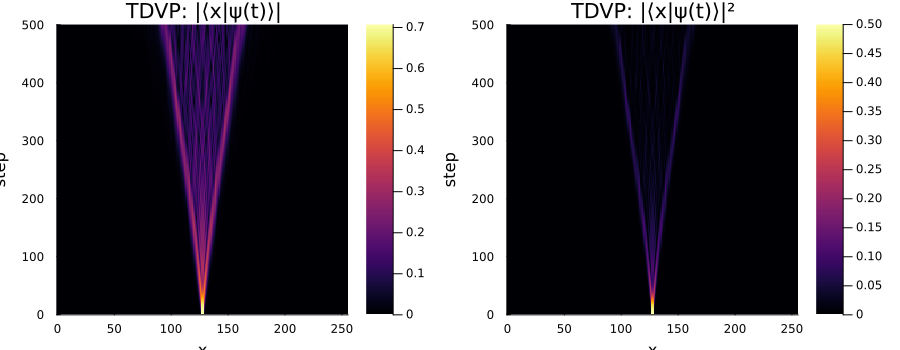

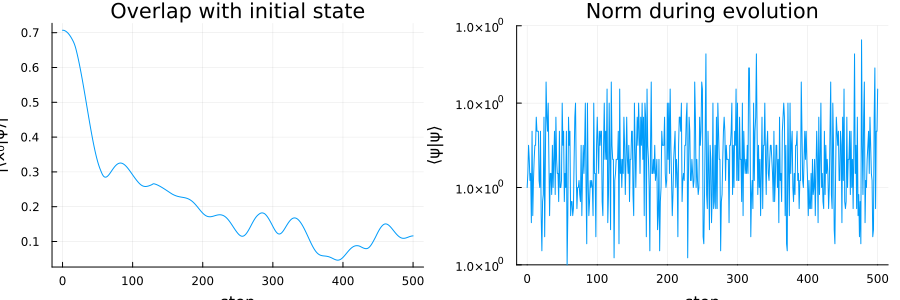

In [57]:
tdvp_data  = TensorBinding.compute_basis_overlaps(tdvp_states, L_t, sites_t)
steps_axis = 0:nsteps_t
basis_axis = 0:(N_t - 1)

p1 = heatmap(basis_axis, steps_axis, tdvp_data.abs_overlaps;
    xlabel="x", ylabel="step", title="TDVP: |⟨x|ψ(t)⟩|", color=:inferno)
p2 = heatmap(basis_axis, steps_axis, tdvp_data.probabilities;
    xlabel="x", ylabel="step", title="TDVP: |⟨x|ψ(t)⟩|²", color=:inferno)
p3 = plot(steps_axis, tdvp_data.abs_overlaps[:, sitemid];
    xlabel="step", ylabel="|⟨x₀|ψ⟩|", title="Overlap with initial state", legend=false)
p4 = plot(steps_axis, tdvp_data.norms;
    xlabel="step", ylabel="⟨ψ|ψ⟩", title="Norm during evolution", legend=false)

display(plot(p1, p2; layout=(1,2), size=(900,350)))
display(plot(p3, p4; layout=(1,2), size=(900,300)))

---
## 6. Driven square lattice — Peierls field and RK4 density-matrix evolution

The x-direction hopping picks up a time-dependent Peierls phase from an AC electric field:

$$H(t) = H_y + t_x \sum_{\langle i,j\rangle_x} \left(e^{i A_x(t)}\, c^\dagger_{i+1} c_i + \text{h.c.}\right)$$

with vector potential $A_x(t) = \frac{E_x}{\omega}\sin(\omega t)\,\Theta(t)$ turned on at $t = 0$.

The single-particle density matrix $\rho(t)$ is propagated by $\dot\rho = -i[H(t),\rho]$ using RK4.

**Efficiency trick**: decompose the Peierls phase as
$$H_x(t) = \cos(A_x)\,H_x^{\rm real} + \sin(A_x)\,H_x^{\rm imag}$$
where $H_x^{\rm real}$, $H_x^{\rm imag}$ are fixed MPOs built once — each time step is then just two scalings and two MPO additions.

In [ ]:
# --- Parameters ---
Ldrv   = 6        # 2^10 = 1024 sites total
Lx_drv = 2^3       # 32x32 square lattice
N_drv  = 2^Ldrv

t_x    = 1.0      # x-hopping amplitude
t_y    = 1.0      # y-hopping (isotropic)
omega  = 1.0      # drive frequency
E_x    = 0.5      # drive amplitude  (A_x peak = E_x/omega)

dt_drv     = 0.1
nsteps_drv = round(Int, 40 * 2pi / (omega * dt_drv))  # 4 full drive cycles

# --- Equilibrium Hamiltonian H0 (no field) ---
H0_drv    = TensorBinding.get_Hamiltonian("square_2d", t_x;
                L=Ldrv, Lx=Lx_drv, scale=9.0)
sites_drv = H0_drv.sites

# --- Pre-build the two static Peierls MPO components ---
#
#   H_x(t) = cos(Ax) * H_x_real + sin(Ax) * H_x_imag
#
#   H_x_real = intrachain_hopping(...; t=t_x)     = t_x*(hop_fwd + hop_bwd)
#   H_x_imag = intrachain_hopping(...; t=im*t_x)  = i*t_x*(hop_fwd - hop_bwd)
#
# With Peierls:  e^{iAx}*hop_fwd + e^{-iAx}*hop_bwd
#              = cos(Ax)*(hop_fwd+hop_bwd) + i*sin(Ax)*(hop_fwd-hop_bwd)
#              = cos(Ax)*H_x_real + sin(Ax)*H_x_imag   (check: i*(hop_fwd-hop_bwd) = H_x_imag/t_x)
H_x_real = TensorBinding.intrachain_hopping(Lx_drv, N_drv, sites_drv; t =      t_x)
H_x_imag = TensorBinding.intrachain_hopping(Lx_drv, N_drv, sites_drv; t = 1im * t_x)
H_y_drv  = TensorBinding.interchain_hopping_square(Lx_drv, N_drv, sites_drv; t = t_y)

# --- Time-dependent Hamiltonian closure (only MPO additions at each call) ---
A_x(t)    = t > 0 ? (E_x / omega) * sin(omega * t) : 0.0

function Hoft_drv(t)
    Ax    = A_x(t)
    H_x_t = +(cos(Ax) * H_x_real, sin(Ax) * H_x_imag; cutoff=1e-10)
    return +(H_x_t, H_y_drv; cutoff=1e-10)
end

# --- Initial density matrix: zero-temperature half-filling ground state of H0 ---
rho0_drv = TensorBinding.mcweeny_purify(H0_drv;
               maxiters=50, maxdim=200, cutoff=1e-8, tol=1e-5, verbose=true)
println("Tr(rho0) = ", real(tr(rho0_drv)), "  (target: ", N_drv / 2, ")")

# --- RK4 time evolution ---
states_drv = TensorBinding.evolve_rk4_dm_timedep(
    Hoft_drv, rho0_drv, nsteps_drv, Float64(dt_drv);
    maxdim=300, cutoff=1e-10, truncate_intermediates=true, verbose=true)

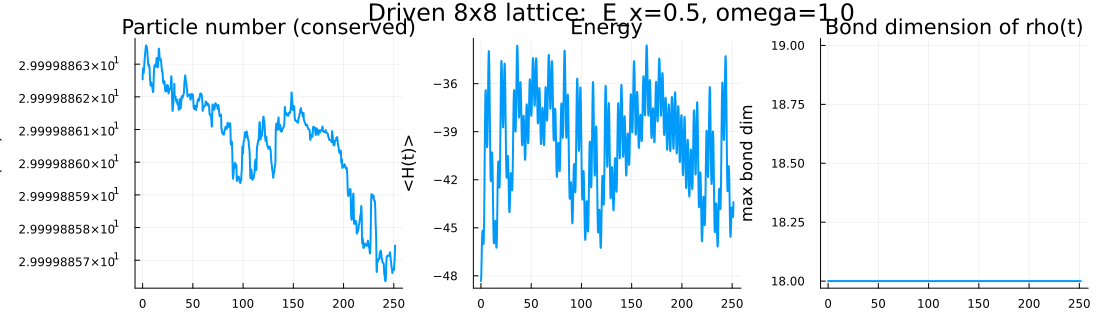

In [3]:
taxis = (0:nsteps_drv) .* dt_drv

# Particle number Tr(rho): conserved under unitary evolution — good sanity check
N_t = [real(tr(rho)) for rho in states_drv]

# Energy Tr(H(t) rho(t)): changes as the field pumps energy in
E_t = TensorBinding.timedep_observable_trajectory(
          Hoft_drv, states_drv, Float64(dt_drv))

# Bond dimension of rho(t): tracks entanglement growth
bonddim_t = [ITensorMPS.maxlinkdim(rho) for rho in states_drv]

p1 = plot(taxis, N_t;
    xlabel="t", ylabel="Tr(rho)", title="Particle number (conserved)",
    lw=2, legend=false)

p2 = plot(taxis, E_t;
    xlabel="t", ylabel="<H(t)>", title="Energy",
    lw=2, legend=false)

p3 = plot(taxis, bonddim_t;
    xlabel="t", ylabel="max bond dim", title="Bond dimension of rho(t)",
    lw=2, legend=false, seriestype=:steppost)

display(plot(p1, p2, p3; layout=(1,3), size=(1100,320),
    plot_title="Driven 8x8 lattice:  E_x=$E_x, omega=$omega"))

Central x-bond: site 35 → 36


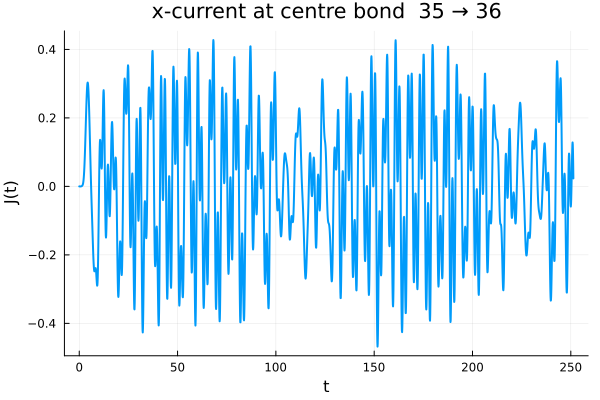

In [4]:
# --- x-current at the centre bond  J(t) = i·t_x(t)·(ρ_{j,j+1} − ρ_{j+1,j}) ---
# Peierls phase: t_x(t) = t_x * exp(i·A_x(t))

j_center = TensorBinding.central_x_bond(Ldrv; Nx=Lx_drv)
println("Central x-bond: site $j_center → $(j_center + 1)")

tx_t(t) = t_x * exp(im * A_x(t))

J_traj = TensorBinding.bond_current_x_trajectory(
    states_drv, j_center, tx_t, Ldrv, sites_drv;
    dt = Float64(dt_drv),
)

plot(taxis, real.(J_traj);
    xlabel  = "t",
    ylabel  = "J(t)",
    title   = "x-current at centre bond  $j_center → $(j_center + 1)",
    lw      = 2,
    legend  = false,
)

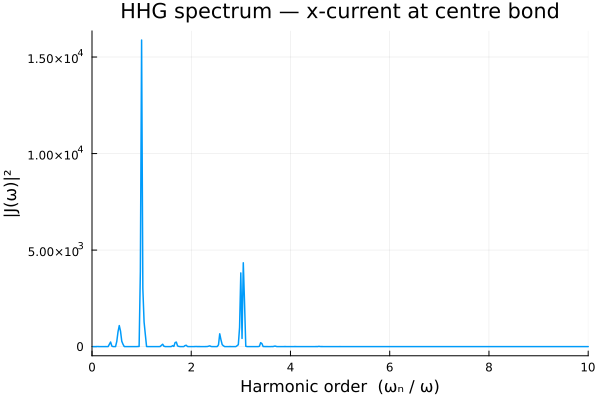

In [8]:
using FFTW

# Hann window to suppress spectral leakage
J_real  = real.(J_traj)
N_fft   = length(J_real)
window  = 0.5 .* (1 .- cos.(2π .* (0:N_fft-1) ./ (N_fft - 1)))

# Power spectrum — positive frequencies only
J_fft   = abs2.(fft(J_real .* window))
freqs_w = 2π .* FFTW.fftfreq(N_fft, 1.0 / dt_drv)   # rad / time
pos     = freqs_w .> 0

plot(freqs_w[pos] ./ omega, J_fft[pos];
    xlabel  = "Harmonic order  (ωₙ / ω)",
    ylabel  = "|J(ω)|²",
    title   = "HHG spectrum — x-current at centre bond",
    lw      = 1.5,
    legend  = false,
    xlims   = (0, min(10, maximum(freqs_w[pos]) / omega)),
)

In [12]:
# -----------------------
# System setup
# -----------------------
L  = 8
H1 = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L)

Ncheb  = 50
maxdim = 100

# Chebyshev expansion
Tn_list, _, scale = TensorBinding.KPM_Tn(H1.mpo, Ncheb, H1.sites; maxdim=maxdim, cutoff = 1e-5)

# -----------------------
# Parameters for Green's function
# -----------------------
ω   = 0.2
η   = 0.03

# Compute Green's function MPO (rescaled Hamiltonian!)
G_kpm = TensorBinding.get_Green_retarded_from_Tn(
    Tn_list, Ncheb, ω;
    η=η, maxdim=maxdim
)

println("maxlinkdim(G_kpm) = ", ITensorMPS.maxlinkdim(G_kpm))

# -----------------------
# Build (ω - H + iη) MPO
# NOTE: must use rescaled Hamiltonian
# -----------------------
Hrescaled = H1.mpo / H1.scale

Id = MPO(H1.sites, "Id")

A = ω * Id - Hrescaled
A = +(A, (1im * η) * Id; maxdim=maxdim)

# -----------------------
# Test inverse property
# Apply A * G ≈ I by acting on random state
# -----------------------
ψ = randomMPS(H1.sites, 2)
ψ = normalize(ψ)

# Apply G then A
ϕ = apply(G_kpm, ψ; maxdim=maxdim)
χ = apply(A, ϕ; maxdim=maxdim)

# Compare with original ψ
overlap = inner(ψ, χ)
norm_diff = norm(χ - ψ)

println("⟨ψ | A G | ψ⟩ = ", overlap)
println("‖(A G - I)ψ‖ = ", norm_diff)

# -----------------------
# Optional: HODC version
# -----------------------
zl, wl = TensorBinding.compute_hodc_params(6)

G_hodc = TensorBinding.get_Green_retarded_from_Tn(
    Tn_list, Ncheb, ω;
    η=η, maxdim=maxdim,
    kernel=:hodc,
    zl=zl, wl=wl
)

ϕ_h = apply(G_hodc, ψ; maxdim=maxdim)
χ_h = apply(A, ϕ_h; maxdim=maxdim)

println("\n[HODC]")
println("⟨ψ | A G | ψ⟩ = ", inner(ψ, χ_h))
println("‖(A G - I)ψ‖ = ", norm(χ_h - ψ))

KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -1.9976,  E_max = 1.9993
  center = 0.0008,  scale = 2.1983
3
5
5
6
7
8
8
8
9
11
11
11
11
11
11
13
14
16
18
19
18
18
19
19
19
21
21
22
23
24
23
23
24
26
26
26
27
27
27
27
27
28
29
29
28
28
28
29
29
maxlinkdim(G_kpm) = 25
⟨ψ | A G | ψ⟩ = 1.009478399077196 - 0.005855303446204189im
‖(A G - I)ψ‖ = 0.06303991746219104

[HODC]
⟨ψ | A G | ψ⟩ = 1.3542547321704883 + 0.27107277250479916im
‖(A G - I)ψ‖ = 1.5109444726553316


KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -1.9981,  E_max = 1.9979
  center = -0.0001,  scale = 2.1978
3
5
5
6
7
8
8
8
9
11
11
11
11
11
11
13
14
16
18
19
18
18
19
19
19
21
21
22
23
23
23
23
24
26
26
26
27
27
27
27
27
28
28
28
28
28
29
28
28
ω = -0.95
ω = -0.9259493670886076
ω = -0.9018987341772152
ω = -0.8778481012658228
ω = -0.8537974683544304
ω = -0.829746835443038
ω = -0.8056962025316455
ω = -0.7816455696202531
ω = -0.7575949367088608
ω = -0.7335443037974684
ω = -0.709493670886076
ω = -0.6854430379746835
ω = -0.6613924050632911
ω = -0.6373417721518987
ω = -0.6132911392405064
ω = -0.589240506329114
ω = -0.5651898734177215
ω = -0.5411392405063291
ω = -0.5170886075949367
ω = -0.4930379746835443
ω = -0.4689873417721519
ω = -0.4449367088607595
ω = -0.4208860759493671
ω = -0.3968354430379747
ω = -0.37278481012658227
ω = -0.3487341772151899
ω = -0.3246835443037975
ω = -0.30063291139240506
ω = -0.27658227848101263
ω = -0.25253164556962027
ω = -0.22848101265822784
ω = -0.2044303

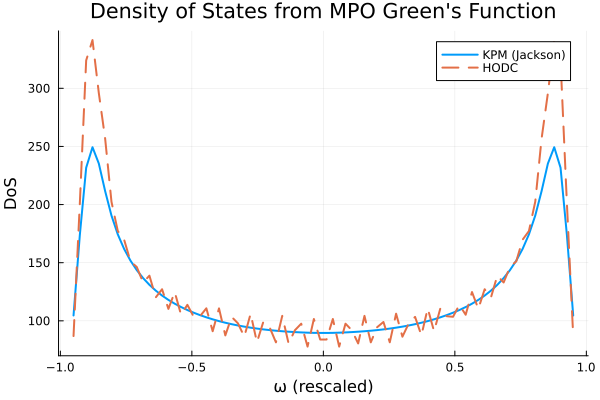

In [2]:
# -----------------------
# System setup
# -----------------------
L  = 8
H1 = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L)

Ncheb  = 50
maxdim = 100

# Chebyshev expansion (returns scale!)
Tn_list, _, scale = TensorBinding.KPM_Tn(
    H1.mpo, Ncheb, H1.sites;
    maxdim=maxdim, cutoff=1e-5
)

# -----------------------
# Frequency grid (rescaled!)
# -----------------------
ω_vals = range(-0.95, 0.95, length=80)
η = 0.03

dos_kpm  = zeros(Float64, length(ω_vals))
dos_hodc = zeros(Float64, length(ω_vals))

# HODC parameters
zl, wl = TensorBinding.compute_hodc_params(3)

# -----------------------
# Loop over frequencies
# -----------------------
for (i, ω) in enumerate(ω_vals)

    # ---- Standard KPM Green's function ----
    G_kpm = TensorBinding.get_Green_retarded_from_Tn(
        Tn_list, Ncheb, ω;
        η=η, maxdim=maxdim
    )

    dos_kpm[i] = -imag(tr(G_kpm)) / π


    # ---- HODC Green's function ----
    G_hodc = TensorBinding.get_Green_retarded_from_Tn(
        Tn_list, Ncheb, ω;
        η=η, maxdim=maxdim,
        kernel=:hodc,
        zl=zl, wl=wl
    )

    dos_hodc[i] = -imag(tr(G_hodc)) / π

    println("ω = ", ω)
end

# -----------------------
# Normalization check
# -----------------------
dω = step(ω_vals)

println("∫ DoS dω (KPM)  ≈ ", sum(dos_kpm) * dω)
println("∫ DoS dω (HODC) ≈ ", sum(dos_hodc) * dω)
println("Expected ≈ ", L)

# -----------------------
# Plot
# -----------------------
plot(ω_vals, dos_kpm, label="KPM (Jackson)", lw=2)
plot!(ω_vals, dos_hodc, label="HODC", lw=2, ls=:dash)

xlabel!("ω (rescaled)")
ylabel!("DoS")
title!("Density of States from MPO Green's Function")

---
## 7. Bernal stacked bilayer graphene — exact interlayer coupling

Bernal (AB) stacked bilayer graphene has two honeycomb layers where each A₁ site
sits directly above a B₂ site of the other layer.

$$H = \sum_{k=1,2} P_k \otimes H_{\text{mono}} + (|1\rangle\langle 2| + |2\rangle\langle 1|) \otimes V_{\text{Bernal}}$$

The interlayer coupling in position space is **built exactly** — no TCI — using shift operators
and a sublattice mask on the quantics grid:

$$V_{\text{Bernal}} = t_\perp \bigl(K_u\, D_A + D_A\, K_d\bigr)$$

where $D_A$ projects onto A-sublattice sites (1-indexed odd) and $K_u, K_d$ are the
$\pm 1$ shift operators.  The resulting MPO has low bond dimension and is exact.

**Honeycomb constraint**: `Lx + Ly` must be odd and `N/2` must be a perfect square.
With `Lx=4, Ly=3`: `L=7`, `N=128` sites per layer, `N/2=64=8²` ✓.

Known physics of Bernal bilayer graphene:
- Low-energy **parabolic** bands near K — the linear Dirac cones of each monolayer
  hybridise through $t_\perp$ into two touching parabolas.
- Two additional dispersive bands at $\pm t_\perp$ (the split Dirac points).
- Finite DoS at $\omega = 0$ (unlike monolayer where it vanishes at the Dirac point).
- Comparison with exact diagonalization validates the exact interlayer MPO construction.

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
Lx_bg  = 4;
Ly_bg  = 3          # L=7, N=128 per layer, N/2=64=8² ✓
t_bg   = 1.0                      # intra-layer NN hopping
t_perp = 0.3                      # Bernal A₁↔B₂ interlayer hopping

# ── Build bilayer Hamiltonian (interlayer exact, no TCI) ──────────────────────
H_bg = TensorBinding.bilayer_hamiltonian(:honeycomb, Lx_bg, Ly_bg;
    stacking = :Bernal,
    t_intra  = t_bg,
    t_inter  = t_perp,
    cutoff   = 1e-8,
    maxdim   = 200,
)
L_bg = Lx_bg + Ly_bg            # 7 position qubits
N_bg = 2^L_bg                   # 128 sites per layer

println("Bilayer graphene MPO  ($(length(H_bg.sites)) sites, maxlinkdim=$(ITensorMPS.maxlinkdim(H_bg.mpo)))")
println("  site 1 (layer qubit) : ", H_bg.sites[1])
println("  sites 2…$(length(H_bg.sites)) (position) : Qubit × $L_bg")
println(H_bg)

# ── KPM density of states ─────────────────────────────────────────────────────
# scale estimated via DMRG automatically on first call (H_bg.scale == 0.0)
Ncheb_bg  = 100
maxdim_bg = 100

TensorBinding.KPM_Tn(H_bg, Ncheb_bg; maxdim=maxdim_bg)

ω_bg_phys = range(-3.5, 3.5; length=120)

dos_bg = Float64[]
for ω_p in ω_bg_phys
    if abs((ω_p - H_bg.center) / H_bg.scale) >= 1.0
        push!(dos_bg, 0.0); continue
    end
    A_mpo = TensorBinding.get_ldos(H_bg, ω_p; maxdim=maxdim_bg)
    push!(dos_bg, real(tr(A_mpo)))
end

# ── Exact diagonalization benchmark ───────────────────────────────────────────
rs_bg = TensorBinding.honeycomb_positions(L_bg)    # N×2 real-space positions

H_mono_dense = zeros(Float64, N_bg, N_bg)
d_NN = 1.0
for i in 1:N_bg, j in (i+1):N_bg
    if abs(norm(rs_bg[i, :] .- rs_bg[j, :]) - d_NN) < 1e-6
        H_mono_dense[i, j] = t_bg
        H_mono_dense[j, i] = t_bg
    end
end

# Bernal coupling: A-site i (odd, 1-indexed) → B-site i+1 (even)
V_dense = zeros(Float64, N_bg, N_bg)
for k in 1:N_bg÷2
    V_dense[2k,   2k-1] = t_perp    # B₂ ← A₁
    V_dense[2k-1, 2k  ] = t_perp    # A₁ ← B₂  (symmetric)
end

H_bg_dense = [H_mono_dense  V_dense;
              V_dense        H_mono_dense]

ε_bg = eigvals(Hermitian(H_bg_dense))

σ_broad  = 0.05
dos_exact_bg = [sum(@. exp(-(ω - ε_bg)^2 / (2σ_broad^2)) / (sqrt(2π) * σ_broad))
                for ω in ω_bg_phys]
dos_exact_bg ./= 2N_bg               # normalise per site

# ── Plot: MPO-KPM vs exact diagonalization ────────────────────────────────────
dos_bg_norm    = dos_bg       ./ maximum(dos_bg)
dos_exact_norm = dos_exact_bg ./ maximum(dos_exact_bg)

p_bg = plot(ω_bg_phys, dos_bg_norm;
    label   = "MPO-KPM (Ncheb=$Ncheb_bg)",
    xlabel  = "Energy (t)",
    ylabel  = "DoS (normalised)",
    title   = "Bernal bilayer graphene DoS  (N=$(2N_bg) sites, t⊥=$t_perp)",
    lw      = 2,
    color   = :firebrick)
plot!(p_bg, ω_bg_phys, dos_exact_norm;
    label  = "Exact diag (σ=$σ_broad t)",
    lw     = 2,
    ls     = :dash,
    color  = :steelblue)

vline!(p_bg, [-t_perp, t_perp];
    ls=:dot, color=:gray, alpha=0.7, label="±t⊥ = ±$t_perp")

---
## 8. SSH model — DoS via Krylov Green's function

The Su-Schrieffer-Heeger (SSH) model has alternating bond strengths `t₁ = t + d`
and `t₂ = t − d`:

$$H = -t_1 \sum_{i \text{ even}} c^\dagger_{i+1} c_i - t_2 \sum_{i \text{ odd}} c^\dagger_{i+1} c_i + \text{h.c.}$$

The spectrum has two bands separated by a gap of width `2(t₁ − t₂) = 4d`.  When
`t₁ > t₂` (`d > 0`) the chain is in the **topological phase** and carries zero-energy
edge states on a finite chain.

Rather than KPM (Chebyshev expansion), here the DoS is computed directly from the
retarded Green's function

$$G(\omega) = (\omega + i\eta - H)^{-1}$$

via `get_green_krylov`, which solves the vectorized linear system
`[(ω + iη − H) ⊗ I]|G⟩⟩ = |I⟩⟩` using ITensorMPS `linsolve`.

$$\text{DoS}(\omega) = -\frac{1}{\pi} \operatorname{Im} \operatorname{Tr}[G(\omega)]$$

The two phases are compared:
- **Topological** (`d = +0.4`): gap ≈ 1.6 centred at zero; edge states visible at ω ≈ 0 for open boundaries.
- **Trivial** (`d = −0.4`): identical bulk bands, same gap width, but no edge states.

In [35]:
L_ssh   = 7        # 2^7 = 128 sites
t_ssh   = 1.0      # mean hopping
d_top   = 0.4      # d > 0 → topological  (t₁ = 1.4, t₂ = 0.6)
d_triv  = -0.4     # d < 0 → trivial      (t₁ = 0.6, t₂ = 1.4)

H_triv  = TensorBinding.get_Hamiltonian("ssh", (t=t_ssh, d=d_top);  L=L_ssh)
H_top = TensorBinding.get_Hamiltonian("ssh", (t=t_ssh, d=d_triv); L=L_ssh)

println(H_top)
println(H_triv)

TBHamiltonian | L=7, N=128, scale=2.5, maxlinkdim=3 | geometry: 128 sites, 1D | no Tn cache
TBHamiltonian | L=7, N=128, scale=2.5, maxlinkdim=3 | geometry: 128 sites, 1D | no Tn cache


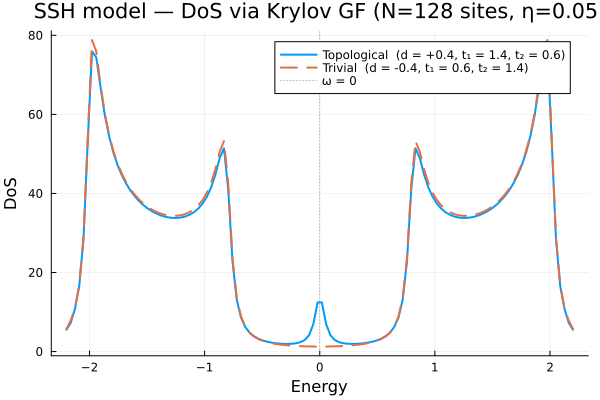

In [36]:
# Krylov GF parameters
η_ssh    = 0.05       # Lorentzian broadening
nsweeps  = 10
maxdim   = 50
cutoff   = 1e-7

ω_ssh = range(-2.2, 2.2; length=120)

dos_triv  = Float64[]
dos_top = Float64[]

for ω_p in ω_ssh
    G_triv  = TensorBinding.get_green_krylov(H_triv,  ω_p; η=η_ssh, nsweeps=nsweeps, maxdim=maxdim, cutoff=cutoff)
    G_top = TensorBinding.get_green_krylov(H_top, ω_p; η=η_ssh, nsweeps=nsweeps, maxdim=maxdim, cutoff=cutoff)
    push!(dos_top,  -imag(tr(G_top))  / π)
    push!(dos_triv, -imag(tr(G_triv)) / π)
end

plot(ω_ssh, dos_top;
     label  = "Topological  (d = +$(d_top), t₁ = $(t_ssh + d_top), t₂ = $(t_ssh - d_top))",
     lw=2, xlabel="Energy", ylabel="DoS",
     title  = "SSH model — DoS via Krylov GF (N=$(2^L_ssh) sites, η=$η_ssh)")
plot!(ω_ssh, dos_triv;
     label  = "Trivial  (d = $(d_triv), t₁ = $(t_ssh + d_triv), t₂ = $(t_ssh - d_triv))",
     lw=2, ls=:dash)
vline!([0.0]; ls=:dot, color=:gray, alpha=0.6, label="ω = 0")

---
## 9. RPA susceptibility via Wynn ε-algorithm

The Random Phase Approximation resums the Dyson series for the interacting
susceptibility:

$$\chi_\text{RPA} = \Pi_0 + \Pi_0 V \Pi_0 + \Pi_0 V \Pi_0 V \Pi_0 + \cdots
= (I - \Pi_0 V)^{-1} \Pi_0$$

where $\Pi_0(\omega)$ is the non-interacting polarization bubble and $V$ is the
bare interaction.

**Efficient workflow** (two improvements over the raw MPO approach):

1. **Density matrix once** — $P = \theta(\mu - H)$ is computed a single time via
   McWeeny purification and cached in `H._density_cache`.  All frequencies share
   the same $P$; no KPM loop is needed.

2. **Wynn ε-algorithm** — instead of solving the large linear system $(I - \Pi_0 V)\chi = \Pi_0$
   at every $\omega$, we build the Neumann series
   $T_0 = \Pi_0$, $T_n = T_{n-1} V \Pi_0$, extract scalars
   $s_n(q) = -\operatorname{Im}\langle q | T_n | q \rangle / \pi$ via `get_spect_k`,
   and apply the Wynn ε-algorithm to the partial-sum sequence $[S_0, S_1, \ldots, S_K]$
   per $(q, \omega)$.  With $K = 6$ terms, the Padé estimate $\varepsilon_6$ typically
   converges as well as hundreds of MPO solves.

All of this is exposed through the single call `get_rpa_susceptibility_wynn`.

In [3]:
# ── System ────────────────────────────────────────────────────────────────────
# Reuse H1 from section 1 (L=5, N=32, 1D nearest-neighbour chain).
# The density matrix is computed once via McWeeny purification and
# stored in H1._density_cache.  Every call to get_bubble_mpo with
# P_method=:purification will find it there and skip recomputation.

println("Pre-computing P via McWeeny purification...")
TensorBinding.mcweeny_purify(H1; maxiters=40, maxdim=100, cutoff=1e-8, tol=1e-5, verbose=false)
println("Tr(P) = ", real(tr(H1._density_cache)),
        "  (target N/2 = ", H1.N ÷ 2, ")")
println("maxlinkdim(P) = ", ITensorMPS.maxlinkdim(H1._density_cache))

# ── Interaction ───────────────────────────────────────────────────────────────
# On-site Hubbard-U: V(i,j) = U·δ(i,j)  →  MPOV = U × identity MPO
U_hub = 2.0
MPOV  = U_hub * MPO(H1.sites, "Id")
println("\nInteraction: on-site Hubbard U = $U_hub")

Pre-computing P via McWeeny purification...


Tr(P) = 15.99996522081863  (target N/2 = 16)
maxlinkdim(P) = 13

Interaction: on-site Hubbard U = 2.0


In [4]:
using Printf

# ── Wynn RPA sweep ────────────────────────────────────────────────────────────
# get_rpa_susceptibility_wynn builds T₀ = Π₀, Tₙ = Tₙ₋₁·V·Π₀ at each ω,
# extracts scalars sₙ(q) = -Im⟨q|Tₙ|q⟩/π via get_spect_k, and applies the
# Wynn ε-algorithm to the partial-sum sequence per (q,ω).
#
# P_method=:purification  →  H1._density_cache is reused for every ω (no rebuild)
# GF_method=:kpm          →  Heff scale auto-estimated via DMRG on first call

ωlist_rpa = range(-3.5, 3.5; length=50)
K_max     = 6        # Neumann-series orders beyond Π₀ (total K_max+1 terms)

chi_partial, chi_wynn = TensorBinding.get_rpa_susceptibility_wynn(
    H1, MPOV, ωlist_rpa;
    K_max        = K_max,
    P_method     = :purification,
    GF_method    = :krylov,
    Ncheb        = 60,
    maxdim       = 100,
    cutoff       = 1e-5,
    maxdim_apply = 200,
    cutoff_apply = 1e-5,
    η            = 0.1,
    verbose      = true,
)

nω, nq   = size(chi_partial, 2), size(chi_partial, 3)
n_wynn   = K_max ÷ 2
@printf("Done: %d ω × %d q grid, %d Wynn estimates per point.\n", nω, nq, n_wynn)

Wynn RPA: ω 1/50  (ω = -3.5)
RPA: computing P1 (P_method=purification)...
  Reusing cached density matrix
RPA: computing P2...
  Reusing cached density matrix
RPA: computed numerator
Krylov GF: ω = -3.5 + 0.1i  (N=10, maxdim=100, nsweeps=12)
RPA: computed Heff GF (GF_method=krylov)
RPA: assembled bubble
  done (7 terms, 3 Wynn estimates)
Wynn RPA: ω 2/50  (ω = -3.357142857142857)
RPA: computing P1 (P_method=purification)...
  Reusing cached density matrix
RPA: computing P2...
  Reusing cached density matrix
RPA: computed numerator
Krylov GF: ω = -3.357142857142857 + 0.1i  (N=10, maxdim=100, nsweeps=12)
RPA: computed Heff GF (GF_method=krylov)
RPA: assembled bubble


LoadError: UndefVarError: `nq` not defined in local scope
Suggestion: check for an assignment to a local variable that shadows a global of the same name.

In [ ]:
q_axis = 0:nq-1
ω_axis = collect(ωlist_rpa)

# ── Panel 1: Π₀ vs best Wynn estimate ─────────────────────────────────────────
# chi_partial[1,...] = partial sum at K=0, i.e. bare Π₀(q,ω)
# chi_wynn[n_wynn,...] = highest Padé estimate, using K_max+1 terms total
p_pi0 = heatmap(q_axis, ω_axis, chi_partial[1, :, :];
    title="Π₀(q,ω)  [bare bubble]",
    xlabel="q", ylabel="ω", color=:inferno)

p_rpa = heatmap(q_axis, ω_axis, chi_wynn[n_wynn, :, :];
    title="χ_RPA(q,ω)  [Wynn ε_$(2n_wynn), $(K_max+1) terms]",
    xlabel="q", ylabel="ω", color=:inferno)

display(plot(p_pi0, p_rpa; layout=(1, 2), size=(860, 360),
    plot_title="RPA susceptibility  (U = $U_hub, N = $(H1.N))"))

# ── Panel 2: Convergence of partial sums vs Wynn estimates ────────────────────
# Total spectral weight Σ_{q,ω} |−Im χ| at each approximation level
spec_partial = [sum(abs.(chi_partial[k+1, :, :])) for k in 0:K_max]
spec_wynn    = [sum(abs.(chi_wynn[m, :, :]))       for m in 1:n_wynn]

p_conv = plot(0:K_max, spec_partial;
    label="Partial sum K", lw=2, marker=:circle, color=:crimson,
    xlabel="Order K  (number of terms = K+1)",
    ylabel="Σ_{q,ω} |−Im χ|",
    title="Convergence: Neumann series vs Wynn ε-acceleration")

for m in 1:n_wynn
    scatter!(p_conv, [2m], [spec_wynn[m]];
        label="Wynn ε_$(2m)  ($(2m+1) terms)",
        markersize=9, markershape=:star5)
end

hline!(p_conv, [spec_wynn[end]]; lw=1, ls=:dot, color=:gray,
    label="Wynn ε_$(2n_wynn) (best estimate)")

display(plot(p_conv; size=(680, 400)))